✓ All imports successful!
✓ Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Save directory: /content/drive/MyDrive/adversarial_robustness/saved_models

LOADING CIFAR-10 DATASET
✓ Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
✓ Training samples: 50000, Test samples: 10000
✓ SimpleCNN model defined
✓ Attack functions defined (FGSM, PGD, C&W, DeepFool, AutoAttack)
✓ Detection functions defined (Confidence, Stability, Hybrid, Safe Predict)
✓ Preprocessing defenses defined (JPEG, Gaussian, Median)
✓ Training functions defined (Standard, FGSM Adversarial, PGD Adversarial)
✓ Evaluation functions defined
✓ Randomized Smoothing classifier defined
✓ Real-Time Hardening System defined
✓ Model management functions defined

TRAINING/LOADING MODELS
✓ Baseline model loaded from checkpoint
✓ Robust model loaded from checkpoint

✓ Both models ready!


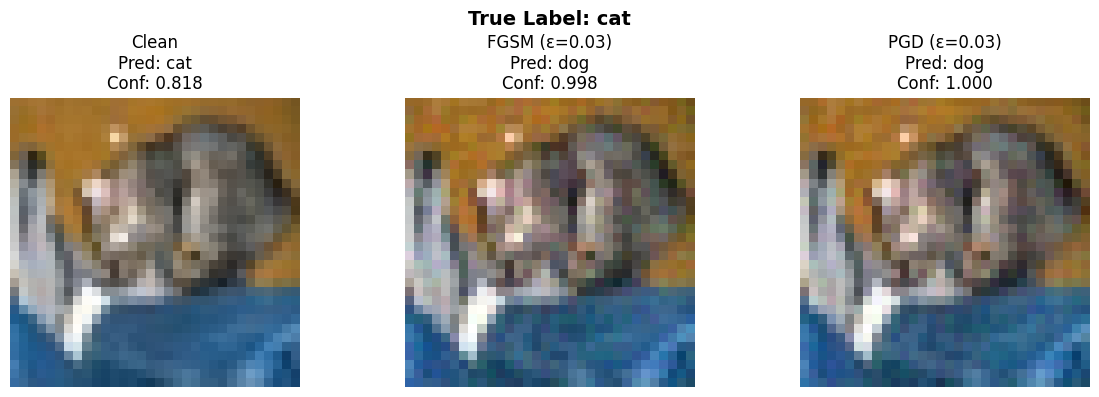

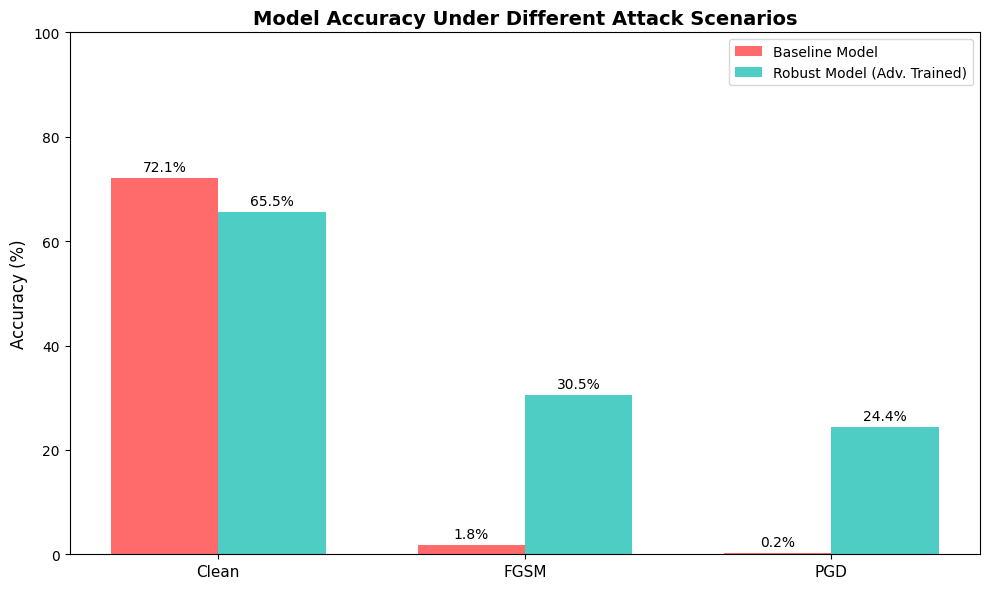


DETECTION METRICS

FGSM Detection Metrics:
  TP: 274
  FP: 411
  TN: 869
  FN: 1006
  Precision: 0.4000
  Recall: 0.2141
  F1: 0.2789

PGD Detection Metrics:
  TP: 50
  FP: 411
  TN: 869
  FN: 1230
  Precision: 0.1085
  Recall: 0.0391
  F1: 0.0574

🎮 INTERACTIVE ADVERSARIAL ROBUSTNESS UI
Use the controls below to explore attacks and defenses interactively!



🎯 PROJECT SUMMARY: ADVERSARIAL ROBUSTNESS AND DEFENSE SYSTEM

📊 KEY FINDINGS:

1. VULNERABILITY: Deep learning models are highly vulnerable to adversarial attacks
   • FGSM attack significantly reduces accuracy with minimal perturbation
   • PGD attack (stronger, iterative) is even more effective

2. DETECTION: Multiple detection methods available
   • Confidence-based: Low confidence → likely adversarial
   • Stability-based: High variance under noise → likely adversarial
   • Hybrid: Combines both for better detection

3. DEFENSE STRATEGIES:
   • Adversarial Training: Train on adversarial examples → improved robustness
   • Preprocessing: JPEG, Gaussian smoothing, Median filter
   • Randomized Smoothing: Certified robustness guarantees
   • Real-time Hardening: Continuous learning from detected examples

4. TRADE-OFFS:
   • Robustness vs Accuracy: Slight clean accuracy drop for better adversarial robustness
   • Detection with Rejection: Lower coverage but higher reliability

✅ IMPL

In [ ]:
# =============================================================================
# 🛡️ ADVERSARIAL ROBUSTNESS AND DEFENSE SYSTEM FOR DEEP LEARNING MODELS
# =============================================================================
# Complete Single-Cell Implementation for Google Colab
# Just copy this entire code and paste into a single Colab cell, then run!
# =============================================================================

"""
===============================================================================
🛡️ PROJECT TITLE:
Adversarial Robustness and Defense System for Deep Learning Models
===============================================================================

🎯 PROJECT SCOPE:

This project aims to design and implement a complete end-to-end adversarial
robustness pipeline for deep learning-based image classification systems.
The primary objective is to analyze vulnerabilities of neural networks to
adversarial attacks and develop effective detection and defense mechanisms,
along with a real-time adaptive hardening system.

The system is built using the CIFAR-10 dataset and a Convolutional Neural
Network (CNN) model. It simulates realistic adversarial attack scenarios and
demonstrates how such attacks can degrade model performance. The project then
introduces multiple layers of defense to improve robustness and reliability.

-------------------------------------------------------------------------------
🔍 CORE COMPONENTS:
-------------------------------------------------------------------------------

1. BASE MODEL:
   A CNN-based image classifier is trained on the CIFAR-10 dataset to serve
   as the target model for adversarial evaluation.

2. ADVERSARIAL ATTACKS:
   The system implements multiple adversarial attack techniques to test model
   vulnerability:
   - FGSM (Fast Gradient Sign Method)
   - PGD (Projected Gradient Descent)
   - C&W (Carlini & Wagner Attack)
   - DeepFool Attack
   - AutoAttack (ensemble-based attack)

   These attacks simulate real-world scenarios where malicious inputs attempt
   to mislead the model.

3. ADVERSARIAL DETECTION:
   The project incorporates multiple detection strategies:
   - Confidence-based detection (low confidence → suspicious input)
   - Stability-based detection (high output variance under noise)
   - Hybrid detection combining both methods

4. DEFENSE MECHANISMS:
   Several defense techniques are implemented to mitigate adversarial effects:
   - Adversarial training (FGSM and PGD)
   - Input preprocessing (JPEG compression, Gaussian smoothing, Median filtering)
   - Randomized smoothing for certified robustness
   - Safe prediction with rejection of uncertain inputs

5. REAL-TIME HARDENING SYSTEM:
   A dynamic system is developed to simulate real-world deployment:
   - Detects adversarial inputs during inference
   - Stores suspicious samples in a buffer
   - Periodically retrains the model using collected adversarial data
   - Continuously improves robustness over time

6. INTERACTIVE USER INTERFACE:
   An interactive UI is built using ipywidgets to:
   - Select model (baseline or robust)
   - Apply different attacks and defenses
   - Visualize original, attacked, and defended images
   - Display predictions, confidence, and detection results

-------------------------------------------------------------------------------
⚙️ SYSTEM PIPELINE:
-------------------------------------------------------------------------------

   Input Image
        ↓
   Adversarial Attack (optional)
        ↓
   Detection Module (Confidence + Stability)
        ↓
   Defense Mechanism (if required)
        ↓
   Final Prediction
        ↓
   Logging + Buffer Storage
        ↓
   Periodic Retraining (Real-Time Hardening)

-------------------------------------------------------------------------------
📊 EVALUATION METRICS:
-------------------------------------------------------------------------------

The system is evaluated using:
- Clean accuracy vs adversarial accuracy
- Detection metrics (TP, FP, TN, FN, Precision, Recall, F1 Score)
- Robustness improvement after adversarial training
- Visualization of perturbations and predictions

-------------------------------------------------------------------------------
🚀 KEY CONTRIBUTIONS:
-------------------------------------------------------------------------------

- Demonstrates real-world vulnerability of deep learning models
- Provides a multi-layer defense architecture
- Implements real-time adaptive learning system
- Combines detection, defense, and retraining in one pipeline
- Includes an interactive UI for experimentation and demonstration

-------------------------------------------------------------------------------
📌 APPLICATIONS:
-------------------------------------------------------------------------------

This system is applicable in security-critical domains such as:
- Autonomous driving systems
- Face recognition systems
- Medical image analysis
- Surveillance and security systems

-------------------------------------------------------------------------------
⚠️ LIMITATIONS:
-------------------------------------------------------------------------------

- Tested only on CIFAR-10 (small-scale dataset)
- Real-time retraining is simulated, not production-scale
- Computational overhead increases with defense mechanisms

-------------------------------------------------------------------------------
✅ CONCLUSION:
-------------------------------------------------------------------------------

The project successfully demonstrates that deep learning models are highly
vulnerable to adversarial attacks, but robustness can be significantly improved
using a combination of detection, defense, and continuous learning strategies.
This work highlights the importance of building secure and reliable AI systems
for real-world applications.

===============================================================================
"""

# =============================================================================
# SECTION 1: INSTALL DEPENDENCIES
# =============================================================================
!pip install torch torchvision matplotlib numpy tqdm scikit-learn scipy pillow ipywidgets -q

# =============================================================================
# SECTION 2: IMPORTS
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import numpy as np
import time
import random
import os
import sys
import io
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import roc_curve, auc
from scipy.stats import norm, beta

import ipywidgets as widgets
from IPython.display import display, clear_output

print("✓ All imports successful!")

# =============================================================================
# SECTION 3: CONFIGURATION
# =============================================================================
# Random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")

# Hyperparameters
EPSILON = 0.03          # Perturbation budget (L-infinity)
ALPHA = 0.007           # PGD step size
PGD_ITERS = 10          # PGD iterations
CONF_THRESHOLD = 0.7    # Confidence threshold for detection
STAB_THRESHOLD = 0.005  # Stability threshold for detection

# Persistent storage setup
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PERSIST_ROOT = '/content/drive/MyDrive/adversarial_robustness'
else:
    PERSIST_ROOT = '.'

SAVE_DIR = os.path.join(PERSIST_ROOT, 'saved_models')
os.makedirs(SAVE_DIR, exist_ok=True)
BASELINE_PATH = os.path.join(SAVE_DIR, 'baseline_model.pth')
ROBUST_PATH = os.path.join(SAVE_DIR, 'robust_model.pth')

print(f"✓ Save directory: {SAVE_DIR}")

# =============================================================================
# SECTION 4: LOAD CIFAR-10 DATASET
# =============================================================================
print("\n" + "="*70)
print("LOADING CIFAR-10 DATASET")
print("="*70)

transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = trainset.classes
print(f"✓ Classes: {classes}")
print(f"✓ Training samples: {len(trainset)}, Test samples: {len(testset)}")

# =============================================================================
# SECTION 5: MODEL ARCHITECTURE
# =============================================================================
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification
    Architecture: Conv(3->32) -> Pool -> Conv(32->64) -> Pool -> FC(4096->256) -> FC(256->10)
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

criterion = nn.CrossEntropyLoss()
print("✓ SimpleCNN model defined")

# =============================================================================
# SECTION 6: ATTACK FUNCTIONS
# =============================================================================
def fgsm_attack(model, images, labels, epsilon=EPSILON):
    """Fast Gradient Sign Method (FGSM) Attack"""
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    images.requires_grad = True

    outputs = model(images)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)
    return adv_images.detach()


def pgd_attack(model, images, labels, epsilon=EPSILON, alpha=ALPHA, iters=PGD_ITERS):
    """Projected Gradient Descent (PGD) Attack"""
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    original_images = images.clone().detach()

    for _ in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()

        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, -epsilon, epsilon)
        images = torch.clamp(original_images + eta, 0, 1).detach()

    return images


def cw_attack(model, images, labels, c=1.0, kappa=0, max_iter=100, lr=0.01):
    """Carlini & Wagner (C&W) Attack"""
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    w = torch.zeros_like(images, requires_grad=True, device=device)
    optimizer = optim.Adam([w], lr=lr)

    best_adv = images.clone()
    best_l2 = torch.full((images.size(0),), float('inf'), device=device)

    for _ in range(max_iter):
        adv_images = 0.5 * (torch.tanh(w) + 1)
        l2_dist = ((adv_images - images) ** 2).sum(dim=(1, 2, 3))
        outputs = model(adv_images)

        one_hot = F.one_hot(labels, num_classes=10).float()
        real = (one_hot * outputs).sum(dim=1)
        other = ((1 - one_hot) * outputs - one_hot * 1e4).max(dim=1)[0]
        f_loss = torch.clamp(real - other, min=-kappa)

        loss = l2_dist.sum() + c * f_loss.sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        adv_images_detached = adv_images.detach()
        pred = outputs.argmax(dim=1)
        successful = pred != labels

        for i in range(images.size(0)):
            if successful[i] and l2_dist[i] < best_l2[i]:
                best_l2[i] = l2_dist[i]
                best_adv[i] = adv_images_detached[i]

    return best_adv.detach()


def deepfool_attack(model, images, labels, max_iter=50, overshoot=0.02):
    """DeepFool Attack - finds minimal perturbation"""
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    batch_size = images.size(0)
    adv_images = images.clone()

    for b in range(batch_size):
        img = images[b:b+1].clone().requires_grad_(True)
        label = labels[b].item()

        for _ in range(max_iter):
            output = model(img)
            pred = output.argmax(dim=1).item()

            if pred != label:
                break

            num_classes = output.size(1)
            gradients = []

            for k in range(num_classes):
                if img.grad is not None:
                    img.grad.zero_()
                output[0, k].backward(retain_graph=True)
                gradients.append(img.grad.clone())

            grad_orig = gradients[label]
            min_pert = float('inf')
            best_w = None
            best_f = None

            for k in range(num_classes):
                if k == label:
                    continue
                w_k = gradients[k] - grad_orig
                f_k = output[0, k] - output[0, label]
                pert = abs(f_k.item()) / (w_k.norm().item() + 1e-8)

                if pert < min_pert:
                    min_pert = pert
                    best_w = w_k
                    best_f = f_k

            if best_w is not None:
                r = (abs(best_f.item()) / (best_w.norm().item() ** 2 + 1e-8)) * best_w
                img = torch.clamp(img + (1 + overshoot) * r, 0, 1).detach().requires_grad_(True)

        adv_images[b] = img.detach()

    return adv_images


def auto_attack(model, images, labels, epsilon=EPSILON):
    """AutoAttack - Ensemble of attacks"""
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    batch_size = images.size(0)

    best_adv = images.clone()
    best_loss = torch.zeros(batch_size, device=device)

    # Attack 1: Standard PGD
    adv1 = pgd_attack(model, images, labels, epsilon=epsilon, alpha=epsilon/4, iters=20)
    with torch.no_grad():
        out1 = model(adv1)
        loss1 = F.cross_entropy(out1, labels, reduction='none')
    mask1 = loss1 > best_loss
    best_adv[mask1] = adv1[mask1]
    best_loss[mask1] = loss1[mask1]

    # Attack 2: DLR loss PGD
    def dlr_loss(outputs, labels):
        sorted_logits, _ = outputs.sort(dim=1, descending=True)
        correct_logits = outputs.gather(1, labels.unsqueeze(1)).squeeze()
        max_other = sorted_logits[:, 0]
        max_other[sorted_logits[:, 0] == correct_logits] = sorted_logits[:, 1][sorted_logits[:, 0] == correct_logits]
        return -(correct_logits - max_other) / (sorted_logits[:, 0] - sorted_logits[:, 2] + 1e-8)

    adv2 = images.clone().detach()
    for _ in range(20):
        adv2.requires_grad = True
        outputs = model(adv2)
        loss = dlr_loss(outputs, labels).sum()
        model.zero_grad()
        loss.backward()
        adv2 = adv2 + (epsilon/4) * adv2.grad.sign()
        eta = torch.clamp(adv2 - images, -epsilon, epsilon)
        adv2 = torch.clamp(images + eta, 0, 1).detach()

    with torch.no_grad():
        out2 = model(adv2)
        loss2 = F.cross_entropy(out2, labels, reduction='none')
    mask2 = loss2 > best_loss
    best_adv[mask2] = adv2[mask2]
    best_loss[mask2] = loss2[mask2]

    return best_adv.detach()

print("✓ Attack functions defined (FGSM, PGD, C&W, DeepFool, AutoAttack)")

# =============================================================================
# SECTION 7: DETECTION FUNCTIONS
# =============================================================================
def detect_adversarial_confidence(outputs, threshold=CONF_THRESHOLD):
    """Confidence-based detection"""
    probs = torch.softmax(outputs, dim=1)
    confidence, _ = probs.max(dim=1)
    return confidence < threshold


def stability_score(model, images, runs=5, noise_std=0.01):
    """Stability-based detection - measures prediction variance under noise"""
    model.eval()
    all_probs = []

    with torch.no_grad():
        for _ in range(runs):
            noisy_images = images + noise_std * torch.randn_like(images)
            noisy_images = torch.clamp(noisy_images, 0, 1)
            outputs = model(noisy_images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs)

    all_probs = torch.stack(all_probs, dim=0)
    variance = all_probs.var(dim=0).mean(dim=1)
    return variance


def hybrid_detect(model, images, conf_thresh=CONF_THRESHOLD, stab_thresh=STAB_THRESHOLD):
    """Hybrid detection combining confidence and stability"""
    model.eval()

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, _ = probs.max(dim=1)

    stab_scores = stability_score(model, images)
    low_confidence = confidence < conf_thresh
    high_instability = stab_scores > stab_thresh

    return low_confidence | high_instability


def safe_predict(model, images, threshold=CONF_THRESHOLD):
    """Safe prediction with rejection for low-confidence inputs"""
    model.eval()
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, predictions = probs.max(dim=1)
        predictions = predictions.clone()
        predictions[confidence < threshold] = -1
    return predictions

print("✓ Detection functions defined (Confidence, Stability, Hybrid, Safe Predict)")

# =============================================================================
# SECTION 8: PREPROCESSING DEFENSES
# =============================================================================
def jpeg_compression_defense(images, quality=75):
    """JPEG compression defense"""
    batch_size = images.size(0)
    processed = []

    for i in range(batch_size):
        img = images[i].cpu().numpy()
        img = (img * 255).astype(np.uint8)
        img = np.transpose(img, (1, 2, 0))
        pil_img = Image.fromarray(img)

        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        pil_img = Image.open(buffer)

        img = np.array(pil_img).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        processed.append(torch.from_numpy(img))

    return torch.stack(processed).to(device)


def spatial_smoothing_defense(images, kernel_size=3, sigma=1.0):
    """Gaussian smoothing defense"""
    channels = images.size(1)
    x = torch.arange(kernel_size, dtype=torch.float32, device=device) - kernel_size // 2
    gauss = torch.exp(-x**2 / (2 * sigma**2))
    gauss = gauss / gauss.sum()

    kernel_2d = gauss.unsqueeze(0) * gauss.unsqueeze(1)
    kernel_2d = kernel_2d.expand(channels, 1, kernel_size, kernel_size)

    padding = kernel_size // 2
    smoothed = F.conv2d(images, kernel_2d, padding=padding, groups=channels)
    return smoothed


def median_filter_defense(images, kernel_size=3):
    """Median filter defense"""
    batch_size, channels, H, W = images.size()
    pad = kernel_size // 2
    padded = F.pad(images, (pad, pad, pad, pad), mode='reflect')
    patches = padded.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    patches = patches.contiguous().view(batch_size, channels, H, W, -1)
    filtered = patches.median(dim=-1)[0]
    return filtered

print("✓ Preprocessing defenses defined (JPEG, Gaussian, Median)")

# =============================================================================
# SECTION 9: TRAINING FUNCTIONS
# =============================================================================
def train_standard(model, trainloader, epochs=10, lr=0.001):
    """Standard training on clean images"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{100*correct/total:.2f}%'})

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f} Acc: {100*correct/total:.2f}%")

    return model


def train_adversarial_fgsm(model, trainloader, epochs=10, lr=0.001, epsilon=EPSILON):
    """Adversarial training with FGSM"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Adv Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            adv_images = fgsm_attack(model, images, labels, epsilon)
            all_images = torch.cat([images, adv_images], dim=0)
            all_labels = torch.cat([labels, labels], dim=0)

            optimizer.zero_grad()
            outputs = model(all_images)
            loss = criterion(outputs, all_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += all_labels.size(0)
            correct += predicted.eq(all_labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{100*correct/total:.2f}%'})

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f} Acc: {100*correct/total:.2f}%")

    return model


def train_adversarial_pgd(model, trainloader, epochs=10, lr=0.001, epsilon=EPSILON, alpha=ALPHA, pgd_iters=7):
    """PGD Adversarial Training - stronger robustness"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"PGD Epoch {epoch+1}/{epochs}")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            model.eval()
            adv_images = pgd_attack(model, images, labels, epsilon, alpha, pgd_iters)
            model.train()

            optimizer.zero_grad()
            outputs = model(adv_images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.3f}', 'acc': f'{100*correct/total:.2f}%'})

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f} Acc: {100*correct/total:.2f}%")

    return model

print("✓ Training functions defined (Standard, FGSM Adversarial, PGD Adversarial)")

# =============================================================================
# SECTION 10: EVALUATION FUNCTIONS
# =============================================================================
def evaluate_clean(model, loader):
    """Evaluate on clean images"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100 * correct / total


def evaluate_accuracy(model, loader, attack=None, defense=False):
    """Evaluate accuracy under attacks with optional defense"""
    model.eval()
    correct = 0
    total = 0
    rejected = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if attack == 'fgsm':
            images = fgsm_attack(model, images, labels)
        elif attack == 'pgd':
            images = pgd_attack(model, images, labels)
        elif attack == 'cw':
            images = cw_attack(model, images, labels)
        elif attack == 'auto':
            images = auto_attack(model, images, labels)

        if defense:
            preds = safe_predict(model, images)
            rejected += (preds == -1).sum().item()
            mask = preds != -1
            correct += preds[mask].eq(labels[mask]).sum().item()
            total += mask.sum().item()
        else:
            with torch.no_grad():
                outputs = model(images)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

    acc = 100 * correct / max(total, 1)
    return acc, rejected


def evaluate_detection_metrics(model, loader, attack='fgsm', n_batches=10):
    """Evaluate detection performance metrics"""
    model.eval()
    tp, fp, tn, fn = 0, 0, 0, 0

    for i, (images, labels) in enumerate(loader):
        if i >= n_batches:
            break

        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            out_clean = model(images)
        clean_detected = detect_adversarial_confidence(out_clean)
        fp += clean_detected.sum().item()
        tn += (~clean_detected).sum().item()

        if attack == 'fgsm':
            adv_images = fgsm_attack(model, images, labels)
        else:
            adv_images = pgd_attack(model, images, labels)

        with torch.no_grad():
            out_adv = model(adv_images)
        adv_detected = detect_adversarial_confidence(out_adv)
        tp += adv_detected.sum().item()
        fn += (~adv_detected).sum().item()

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)

    return {'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn, 'Precision': precision, 'Recall': recall, 'F1': f1}

print("✓ Evaluation functions defined")

# =============================================================================
# SECTION 11: RANDOMIZED SMOOTHING
# =============================================================================
class RandomizedSmoothingClassifier:
    """Randomized Smoothing for certified robustness"""

    def __init__(self, base_model, sigma=0.25, n_samples=100, alpha=0.001):
        self.base_model = base_model
        self.sigma = sigma
        self.n_samples = n_samples
        self.alpha = alpha

    def predict(self, images):
        self.base_model.eval()
        batch_size = images.size(0)
        counts = torch.zeros(batch_size, 10, device=device)

        with torch.no_grad():
            for _ in range(self.n_samples):
                noisy = images + self.sigma * torch.randn_like(images)
                noisy = torch.clamp(noisy, 0, 1)
                outputs = self.base_model(noisy)
                preds = outputs.argmax(dim=1)
                for i in range(batch_size):
                    counts[i, preds[i]] += 1

        return counts.argmax(dim=1)

    def certify(self, images, n_samples=1000):
        self.base_model.eval()
        batch_size = images.size(0)
        counts = torch.zeros(batch_size, 10, device=device)

        with torch.no_grad():
            for _ in range(n_samples):
                noisy = images + self.sigma * torch.randn_like(images)
                noisy = torch.clamp(noisy, 0, 1)
                outputs = self.base_model(noisy)
                preds = outputs.argmax(dim=1)
                for i in range(batch_size):
                    counts[i, preds[i]] += 1

        top2 = counts.topk(2, dim=1)
        n_A = top2.values[:, 0]
        predictions = top2.indices[:, 0]
        radii = torch.zeros(batch_size, device=device)

        for i in range(batch_size):
            p_A_lower = beta.ppf(self.alpha, n_A[i].item(), n_samples - n_A[i].item() + 1)
            if p_A_lower > 0.5:
                radii[i] = self.sigma * norm.ppf(p_A_lower)
            else:
                predictions[i] = -1
                radii[i] = 0.0

        return predictions, radii

print("✓ Randomized Smoothing classifier defined")

# =============================================================================
# SECTION 12: REAL-TIME HARDENING SYSTEM
# =============================================================================
class AdversarialBuffer:
    """Buffer to store detected adversarial examples"""

    def __init__(self, max_size=5000):
        self.max_size = max_size
        self.images = []
        self.labels = []
        self.timestamps = []

    def add(self, images, labels):
        batch_size = images.size(0)
        for i in range(batch_size):
            if len(self.images) >= self.max_size:
                self.images.pop(0)
                self.labels.pop(0)
                self.timestamps.pop(0)

            self.images.append(images[i].cpu().clone())
            self.labels.append(labels[i].cpu().clone() if torch.is_tensor(labels[i]) else labels[i])
            self.timestamps.append(time.time())

    def get_dataset(self):
        if len(self.images) == 0:
            return None, None
        images = torch.stack(self.images)
        labels = torch.tensor([l if isinstance(l, int) else l.item() for l in self.labels])
        return images, labels

    def __len__(self):
        return len(self.images)

    def clear(self):
        self.images = []
        self.labels = []
        self.timestamps = []


class RealTimeHardeningSystem:
    """Real-time adversarial hardening system"""

    def __init__(self, model, buffer_size=5000, retrain_threshold=500,
                 conf_threshold=0.7, retrain_epochs=2, retrain_lr=0.0001):
        self.model = model
        self.buffer = AdversarialBuffer(max_size=buffer_size)
        self.retrain_threshold = retrain_threshold
        self.conf_threshold = conf_threshold
        self.retrain_epochs = retrain_epochs
        self.retrain_lr = retrain_lr

        self.total_processed = 0
        self.total_detected = 0
        self.retrain_count = 0
        self.clean_data_sample = None

    def set_clean_data_sample(self, images, labels):
        self.clean_data_sample = (images.cpu(), labels.cpu())

    def predict_and_monitor(self, images, true_labels=None):
        self.model.eval()
        images = images.to(device)

        with torch.no_grad():
            outputs = self.model(images)
            probs = torch.softmax(outputs, dim=1)
            confidence, predictions = probs.max(dim=1)

        detected_mask = confidence < self.conf_threshold

        if detected_mask.any():
            detected_images = images[detected_mask]
            detected_labels = true_labels[detected_mask] if true_labels is not None else predictions[detected_mask]
            self.buffer.add(detected_images, detected_labels)
            self.total_detected += detected_mask.sum().item()

        self.total_processed += images.size(0)

        if len(self.buffer) >= self.retrain_threshold:
            self._retrain()

        return predictions, detected_mask

    def _retrain(self):
        print(f"\n{'='*50}")
        print(f"TRIGGERING RETRAINING (buffer: {len(self.buffer)})")
        print(f"{'='*50}")

        adv_images, adv_labels = self.buffer.get_dataset()
        adv_images = adv_images.to(device)
        adv_labels = adv_labels.to(device)

        if self.clean_data_sample is not None:
            clean_images, clean_labels = self.clean_data_sample
            n_adv = adv_images.size(0)
            n_clean = min(n_adv, clean_images.size(0))
            indices = torch.randperm(clean_images.size(0))[:n_clean]
            all_images = torch.cat([adv_images, clean_images[indices].to(device)])
            all_labels = torch.cat([adv_labels, clean_labels[indices].to(device)])
        else:
            all_images = adv_images
            all_labels = adv_labels

        dataset = TensorDataset(all_images, all_labels)
        loader = DataLoader(dataset, batch_size=64, shuffle=True)

        self.model.train()
        optimizer = optim.Adam(self.model.parameters(), lr=self.retrain_lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.retrain_epochs):
            running_loss = 0
            for batch_images, batch_labels in loader:
                optimizer.zero_grad()
                outputs = self.model(batch_images)
                loss = criterion(outputs, batch_labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            print(f"  Retrain Epoch {epoch+1}/{self.retrain_epochs} | Loss: {running_loss/len(loader):.4f}")

        self.retrain_count += 1
        self.buffer.clear()
        print(f"✓ Retraining complete (total: {self.retrain_count})")
        self.model.eval()

    def get_stats(self):
        return {
            'total_processed': self.total_processed,
            'total_detected': self.total_detected,
            'detection_rate': self.total_detected / max(self.total_processed, 1),
            'buffer_size': len(self.buffer),
            'retrain_count': self.retrain_count
        }

print("✓ Real-Time Hardening System defined")

# =============================================================================
# SECTION 13: MODEL SAVE/LOAD & AUTO-RECOVERY
# =============================================================================
def save_model(model, filepath, metadata=None):
    save_dict = {'model_state_dict': model.state_dict()}
    if metadata:
        save_dict['metadata'] = metadata
    torch.save(save_dict, filepath)
    print(f"✓ Model saved to {filepath}")


def load_model(model_class, filepath):
    checkpoint = torch.load(filepath, map_location=device)
    model = model_class().to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✓ Model loaded from {filepath}")
    return model


def ensure_baseline_model(force_retrain=False):
    model = SimpleCNN().to(device)
    if os.path.exists(BASELINE_PATH) and not force_retrain:
        checkpoint = torch.load(BASELINE_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Baseline model loaded from checkpoint")
    else:
        print("Training baseline model...")
        model = train_standard(model, trainloader, epochs=10)
        save_model(model, BASELINE_PATH, {'training': 'standard', 'epochs': 10})
    return model


def ensure_robust_model(force_retrain=False):
    model = SimpleCNN().to(device)
    if os.path.exists(ROBUST_PATH) and not force_retrain:
        checkpoint = torch.load(ROBUST_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Robust model loaded from checkpoint")
    else:
        print("Training FGSM-robust model...")
        model = train_adversarial_fgsm(model, trainloader, epochs=10)
        save_model(model, ROBUST_PATH, {'training': 'adversarial_fgsm', 'epochs': 10})
    return model

print("✓ Model management functions defined")

# =============================================================================
# SECTION 14: TRAIN/LOAD MODELS
# =============================================================================
print("\n" + "="*70)
print("TRAINING/LOADING MODELS")
print("="*70)

baseline_model = ensure_baseline_model()
robust_model = ensure_robust_model()

print("\n✓ Both models ready!")

# =============================================================================
# SECTION 15: COMPREHENSIVE EVALUATION
# =============================================================================
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

print("\nEvaluating baseline model...")
baseline_clean = evaluate_clean(baseline_model, testloader)
baseline_fgsm, _ = evaluate_accuracy(baseline_model, testloader, attack='fgsm')
baseline_pgd, _ = evaluate_accuracy(baseline_model, testloader, attack='pgd')

print("\nEvaluating robust model...")
robust_clean = evaluate_clean(robust_model, testloader)
robust_fgsm, _ = evaluate_accuracy(robust_model, testloader, attack='fgsm')
robust_pgd, _ = evaluate_accuracy(robust_model, testloader, attack='pgd')

print("\n" + "="*90)
print("RESULTS COMPARISON: BASELINE vs ADVERSARIALLY TRAINED MODEL")
print("="*90)
print(f"\n{'Scenario':<20} | {'Baseline':<15} | {'Robust':<15} | {'Improvement':<15}")
print("-"*90)
print(f"{'Clean':<20} | {baseline_clean:>10.2f}%     | {robust_clean:>10.2f}%     | {robust_clean-baseline_clean:>+10.2f}%")
print(f"{'FGSM Attack':<20} | {baseline_fgsm:>10.2f}%     | {robust_fgsm:>10.2f}%     | {robust_fgsm-baseline_fgsm:>+10.2f}%")
print(f"{'PGD Attack':<20} | {baseline_pgd:>10.2f}%     | {robust_pgd:>10.2f}%     | {robust_pgd-baseline_pgd:>+10.2f}%")
print("="*90)

# =============================================================================
# SECTION 16: VISUALIZATION - ATTACK DEMONSTRATION
# =============================================================================
print("\n" + "="*70)
print("ATTACK VISUALIZATION")
print("="*70)

baseline_model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)

# Single image test
image = images[0:1].to(device)
label = labels[0:1].to(device)
true_class = classes[label.item()]

# Generate attacks
with torch.no_grad():
    out_clean = baseline_model(image)
    prob_clean = torch.softmax(out_clean, dim=1)
    conf_clean, pred_clean = prob_clean.max(dim=1)

adv_fgsm = fgsm_attack(baseline_model, image, label)
with torch.no_grad():
    out_fgsm = baseline_model(adv_fgsm)
    prob_fgsm = torch.softmax(out_fgsm, dim=1)
    conf_fgsm, pred_fgsm = prob_fgsm.max(dim=1)

adv_pgd = pgd_attack(baseline_model, image, label)
with torch.no_grad():
    out_pgd = baseline_model(adv_pgd)
    prob_pgd = torch.softmax(out_pgd, dim=1)
    conf_pgd, pred_pgd = prob_pgd.max(dim=1)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image[0].cpu().permute(1, 2, 0).numpy())
axes[0].set_title(f"Clean\nPred: {classes[pred_clean.item()]}\nConf: {conf_clean.item():.3f}")
axes[0].axis('off')

axes[1].imshow(adv_fgsm[0].cpu().permute(1, 2, 0).numpy())
axes[1].set_title(f"FGSM (ε={EPSILON})\nPred: {classes[pred_fgsm.item()]}\nConf: {conf_fgsm.item():.3f}")
axes[1].axis('off')

axes[2].imshow(adv_pgd[0].cpu().permute(1, 2, 0).numpy())
axes[2].set_title(f"PGD (ε={EPSILON})\nPred: {classes[pred_pgd.item()]}\nConf: {conf_pgd.item():.3f}")
axes[2].axis('off')

plt.suptitle(f"True Label: {true_class}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 17: COMPARISON BAR CHART
# =============================================================================
scenarios = ["Clean", "FGSM", "PGD"]
baseline_accs = [baseline_clean, baseline_fgsm, baseline_pgd]
robust_accs = [robust_clean, robust_fgsm, robust_pgd]

x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_accs, width, label='Baseline Model', color='#ff6b6b')
bars2 = ax.bar(x + width/2, robust_accs, width, label='Robust Model (Adv. Trained)', color='#4ecdc4')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Under Different Attack Scenarios', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 100)

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 18: DETECTION METRICS
# =============================================================================
print("\n" + "="*70)
print("DETECTION METRICS")
print("="*70)

print("\nFGSM Detection Metrics:")
fgsm_metrics = evaluate_detection_metrics(baseline_model, testloader, attack="fgsm")
for k, v in fgsm_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\nPGD Detection Metrics:")
pgd_metrics = evaluate_detection_metrics(baseline_model, testloader, attack="pgd")
for k, v in pgd_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# =============================================================================
# SECTION 19: INTERACTIVE UI FOR DEMONSTRATION
# =============================================================================
print("\n" + "="*70)
print("🎮 INTERACTIVE ADVERSARIAL ROBUSTNESS UI")
print("="*70)
print("Use the controls below to explore attacks and defenses interactively!")

# UI Components
model_selector = widgets.Dropdown(
    options=['Baseline', 'Robust'],
    value='Baseline',
    description='Model:',
    style={'description_width': 'initial'}
)

attack_selector = widgets.Dropdown(
    options=['None', 'FGSM', 'PGD', 'C&W', 'AutoAttack'],
    value='None',
    description='Attack:',
    style={'description_width': 'initial'}
)

defense_selector = widgets.Dropdown(
    options=['None', 'JPEG Compression', 'Gaussian Smoothing', 'Median Filter'],
    value='None',
    description='Defense:',
    style={'description_width': 'initial'}
)

index_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=99,
    step=1,
    description='Sample Index:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

epsilon_slider = widgets.FloatSlider(
    value=0.03,
    min=0.01,
    max=0.1,
    step=0.01,
    description='Epsilon (ε):',
    continuous_update=False,
    style={'description_width': 'initial'}
)

run_button = widgets.Button(
    description='🚀 Run Inference',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def run_inference(b):
    with output:
        clear_output()

        # Select model
        model = baseline_model if model_selector.value == 'Baseline' else robust_model
        model.eval()

        # Get data
        all_images = []
        all_labels = []
        for imgs, lbls in testloader:
            all_images.append(imgs)
            all_labels.append(lbls)
            if len(all_images) * 128 > index_slider.value:
                break

        all_images = torch.cat(all_images, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        image = all_images[index_slider.value:index_slider.value+1].to(device)
        label = all_labels[index_slider.value].item()

        original_image = image.clone()

        # Apply attack
        attack_name = attack_selector.value
        eps = epsilon_slider.value

        if attack_name == 'FGSM':
            image = fgsm_attack(model, image, torch.tensor([label]).to(device), epsilon=eps)
        elif attack_name == 'PGD':
            image = pgd_attack(model, image, torch.tensor([label]).to(device), epsilon=eps)
        elif attack_name == 'C&W':
            image = cw_attack(model, image, torch.tensor([label]).to(device))
        elif attack_name == 'AutoAttack':
            image = auto_attack(model, image, torch.tensor([label]).to(device), epsilon=eps)

        # Apply defense
        defense_name = defense_selector.value
        if defense_name == 'JPEG Compression':
            image = jpeg_compression_defense(image, quality=50)
        elif defense_name == 'Gaussian Smoothing':
            image = spatial_smoothing_defense(image)
        elif defense_name == 'Median Filter':
            image = median_filter_defense(image)

        # Prediction
        with torch.no_grad():
            outputs = model(image)
            probs = torch.softmax(outputs, dim=1)
            confidence, prediction = probs.max(1)

        detected_conf = detect_adversarial_confidence(outputs).item()
        detected_hybrid = hybrid_detect(model, image).item()

        # Calculate perturbation
        perturbation = (image - original_image).abs().max().item()

        # Display
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(original_image[0].cpu().permute(1, 2, 0).numpy())
        axes[0].set_title(f"Original\nTrue: {classes[label]}")
        axes[0].axis('off')

        axes[1].imshow(image[0].cpu().permute(1, 2, 0).numpy())
        axes[1].set_title(f"After Attack/Defense\nPred: {classes[prediction.item()]}")
        axes[1].axis('off')

        # Perturbation visualization
        if attack_name != 'None':
            diff = (image - original_image)[0].cpu().permute(1, 2, 0).numpy()
            diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
            axes[2].imshow(diff)
            axes[2].set_title(f"Perturbation\nMax: {perturbation:.4f}")
        else:
            axes[2].imshow(np.zeros((32, 32, 3)))
            axes[2].set_title("No Perturbation")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        # Results
        print("="*60)
        print("📊 INFERENCE RESULT")
        print("="*60)
        print(f"  Model:              {model_selector.value}")
        print(f"  Attack:             {attack_name}" + (f" (ε={eps})" if attack_name not in ['None', 'C&W'] else ""))
        print(f"  Defense:            {defense_name}")
        print("-"*60)
        print(f"  True Label:         {classes[label]}")
        print(f"  Predicted Label:    {classes[prediction.item()]}")
        print(f"  Confidence:         {confidence.item():.4f}")
        print(f"  Correct:            {'✅ Yes' if prediction.item() == label else '❌ No'}")
        print("-"*60)
        print(f"  Confidence Detector: {'🚨 Adversarial' if detected_conf else '✅ Clean'}")
        print(f"  Hybrid Detector:     {'🚨 Adversarial' if detected_hybrid else '✅ Clean'}")
        print("="*60)

run_button.on_click(run_inference)

# Display UI
ui = widgets.VBox([
    widgets.HTML("<h2>🛡️ Adversarial Robustness Interactive Demo</h2>"),
    widgets.HTML("<p>Select options and click 'Run Inference' to see the results.</p>"),
    widgets.HBox([model_selector, attack_selector, defense_selector]),
    widgets.HBox([index_slider, epsilon_slider]),
    run_button,
    output
], layout=widgets.Layout(padding='10px'))

display(ui)

# =============================================================================
# SECTION 20: FINAL SUMMARY
# =============================================================================
print("\n" + "="*90)
print("🎯 PROJECT SUMMARY: ADVERSARIAL ROBUSTNESS AND DEFENSE SYSTEM")
print("="*90)

print("""
📊 KEY FINDINGS:

1. VULNERABILITY: Deep learning models are highly vulnerable to adversarial attacks
   • FGSM attack significantly reduces accuracy with minimal perturbation
   • PGD attack (stronger, iterative) is even more effective

2. DETECTION: Multiple detection methods available
   • Confidence-based: Low confidence → likely adversarial
   • Stability-based: High variance under noise → likely adversarial
   • Hybrid: Combines both for better detection

3. DEFENSE STRATEGIES:
   • Adversarial Training: Train on adversarial examples → improved robustness
   • Preprocessing: JPEG, Gaussian smoothing, Median filter
   • Randomized Smoothing: Certified robustness guarantees
   • Real-time Hardening: Continuous learning from detected examples

4. TRADE-OFFS:
   • Robustness vs Accuracy: Slight clean accuracy drop for better adversarial robustness
   • Detection with Rejection: Lower coverage but higher reliability

✅ IMPLEMENTED COMPONENTS:
   ✔ Attacks: FGSM, PGD, C&W, DeepFool, AutoAttack
   ✔ Detection: Confidence, Stability, Hybrid
   ✔ Defenses: Adversarial training, Preprocessing, Randomized smoothing
   ✔ Real-time hardening system
   ✔ Interactive UI for demonstration
   ✔ Comprehensive evaluation & visualization

🚀 Use the interactive UI above to explore different attacks and defenses!
""")

print("="*90)
print("✅ ADVERSARIAL ROBUSTNESS PIPELINE COMPLETE!")
print("="*90)
